# Agricultural Production Optimization

This notebook explores crop-growing conditions and builds a multiclass classification model to recommend a crop from soil and climate measurements.

**Dataset:** Agricultural Production Optimization

**Target:** `label` crop category

**Features:** `N`, `P`, `K`, `temperature`, `humidity`, `ph`, and `rainfall`

## 1. Setup

Import the analysis, visualization, and modeling libraries used throughout the notebook.

In [2]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

## 2. Load the Dataset

Read the local copy of the Kaggle dataset. The file was downloaded from `ryandinh/agricultural-production-optimization`.

In [3]:
DATA_PATH = 'data/crop_recommendation.csv'

crop_recommendation_df = pd.read_csv(DATA_PATH)
crop_recommendation_df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


## 3. Initial Data Audit

Check the dataset dimensions, column names, sample records, missing values, and target-class balance.

In [4]:
print(f"Dataset shape: {crop_recommendation_df.shape}")

Dataset shape: (2200, 8)


In [5]:
print("Columns:")
print(crop_recommendation_df.columns.tolist())

Columns:
['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']


In [6]:
crop_recommendation_df.head(10)

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
5,69,37,42,23.058049,83.370118,7.073454,251.055000,rice
6,69,55,38,22.708838,82.639414,5.700806,271.324860,rice
7,94,53,40,20.277744,82.894086,5.718627,241.974195,rice
8,89,54,38,24.515881,83.535216,6.685346,230.446236,rice
9,68,58,38,23.223974,83.033227,6.336254,221.209196,rice


In [7]:
missing_values = crop_recommendation_df.isnull().sum()
missing_values

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [8]:
crop_counts = crop_recommendation_df['label'].value_counts()
crop_counts

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

## 4. Feature Summary

Review the average soil and climate conditions across the full dataset.

In [9]:
condition_features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

dataset_condition_profile = crop_recommendation_df[condition_features].mean().round(2)
dataset_condition_profile

N               50.55
P               53.36
K               48.15
temperature     25.62
humidity        71.48
ph               6.47
rainfall       103.46
dtype: float64

## 5. Crop-Specific Exploration

Use reusable summary functions to compare soil and climate requirements by crop and by feature.

In [10]:
def crop_condition_summary(crop_name):
    selected_crop_rows = crop_recommendation_df.query('label == @crop_name')
    condition_summary = selected_crop_rows[condition_features].agg(['min', 'mean', 'max']).T.round(2)
    condition_summary.columns = ['Minimum', 'Average', 'Maximum']
    return condition_summary

crop_condition_summary('rice')

,Minimum,Average,Maximum
N,60.00,79.89,99.00
P,35.00,47.58,60.00
K,35.00,39.87,45.00
temperature,20.05,23.69,26.93
humidity,80.12,82.27,84.97
ph,5.01,6.43,7.87
rainfall,182.56,236.18,298.56


In [11]:
def rank_crops_by_condition(condition_name):
    return (
        crop_recommendation_df.groupby('label')[condition_name]
        .mean()
        .sort_values(ascending=False)
        .round(2)
        .rename(f'Average {condition_name}')
    )

rank_crops_by_condition('rainfall').head(10)

label
rice           236.18
coconut        175.69
jute           174.79
coffee         158.07
pigeonpeas     149.46
papaya         142.63
apple          112.65
orange         110.47
pomegranate    107.53
kidneybeans    105.92
Name: Average rainfall, dtype: float64

In [12]:
def split_crops_around_dataset_average(condition_name):
    dataset_average = crop_recommendation_df[condition_name].mean()
    above_average = crop_recommendation_df.loc[
        crop_recommendation_df[condition_name] > dataset_average,
        'label'
    ].unique()
    at_or_below_average = crop_recommendation_df.loc[
        crop_recommendation_df[condition_name] <= dataset_average,
        'label'
    ].unique()

    return {
        'condition': condition_name,
        'dataset_average': round(dataset_average, 2),
        'crops_above_average': sorted(above_average),
        'crops_at_or_below_average': sorted(at_or_below_average),
    }

split_crops_around_dataset_average('temperature')

{'condition': 'temperature',
 'dataset_average': np.float64(25.62),
 'crops_above_average': ['banana',
  'blackgram',
  'coconut',
  'coffee',
  'cotton',
  'grapes',
  'jute',
  'lentil',
  'maize',
  'mango',
  'mothbeans',
  'mungbean',
  'muskmelon',
  'orange',
  'papaya',
  'pigeonpeas',
  'rice',
  'watermelon'],
 'crops_at_or_below_average': ['apple',
  'banana',
  'blackgram',
  'chickpea',
  'coconut',
  'coffee',
  'cotton',
  'grapes',
  'jute',
  'kidneybeans',
  'lentil',
  'maize',
  'mothbeans',
  'orange',
  'papaya',
  'pigeonpeas',
  'pomegranate',
  'rice',
  'watermelon']}

## 6. Feature Distributions

Plot the distribution of each numeric condition used for crop recommendation.

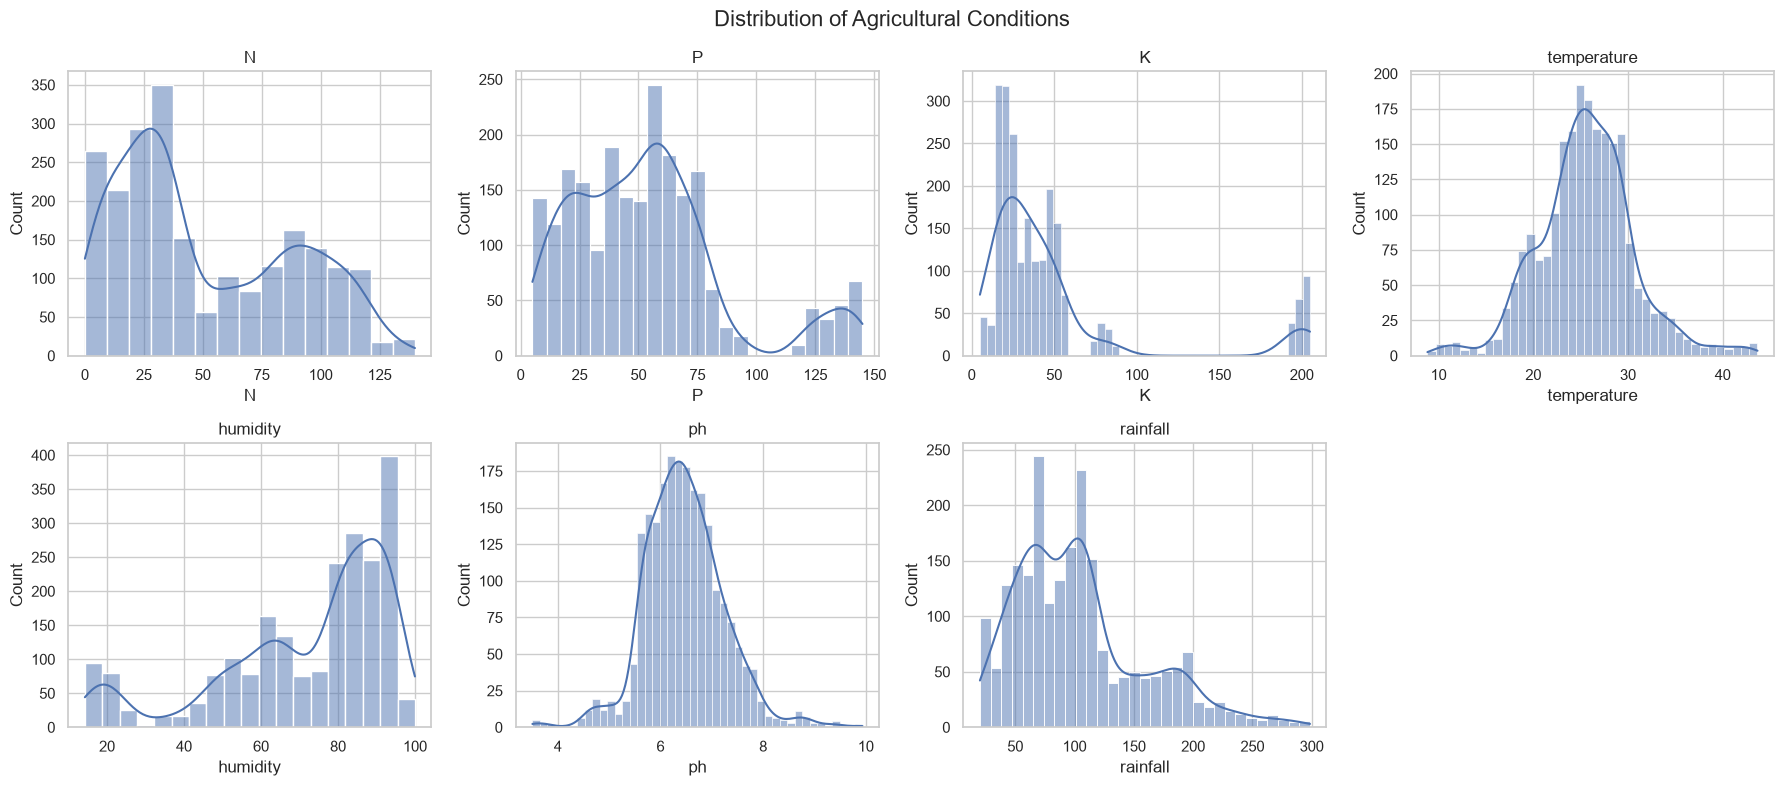

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for axis, condition_name in zip(axes, condition_features):
    sns.histplot(crop_recommendation_df[condition_name], kde=True, ax=axis)
    axis.set_title(condition_name)
    axis.set_xlabel(condition_name)

axes[-1].axis('off')
fig.suptitle('Distribution of Agricultural Conditions', fontsize=16)
plt.tight_layout()
plt.show()

## 7. Agronomic Patterns

Identify crops associated with notably high or low values for key soil and climate conditions.

In [14]:
agronomic_rules = {
    'very high nitrogen': crop_recommendation_df['N'] > 120,
    'very high phosphorus': crop_recommendation_df['P'] > 100,
    'very high potassium': crop_recommendation_df['K'] > 200,
    'very high rainfall': crop_recommendation_df['rainfall'] > 200,
    'very low temperature': crop_recommendation_df['temperature'] < 10,
    'very high temperature': crop_recommendation_df['temperature'] > 40,
    'very low humidity': crop_recommendation_df['humidity'] < 20,
    'very low pH': crop_recommendation_df['ph'] < 4,
    'very high pH': crop_recommendation_df['ph'] > 9,
}

for rule_name, rule_mask in agronomic_rules.items():
    matching_crops = sorted(crop_recommendation_df.loc[rule_mask, 'label'].unique())
    print(f'Crops requiring {rule_name}: {matching_crops}')

Crops requiring very high nitrogen: ['cotton']
Crops requiring very high phosphorus: ['apple', 'grapes']
Crops requiring very high potassium: ['apple', 'grapes']
Crops requiring very high rainfall: ['coconut', 'papaya', 'rice']
Crops requiring very low temperature: ['grapes']
Crops requiring very high temperature: ['grapes', 'papaya']
Crops requiring very low humidity: ['chickpea', 'kidneybeans']
Crops requiring very low pH: ['mothbeans']
Crops requiring very high pH: ['mothbeans']


In [15]:
print('Summer-season crop candidates:')
print(sorted(crop_recommendation_df.loc[(crop_recommendation_df['temperature'] > 30) & (crop_recommendation_df['humidity'] > 50), 'label'].unique()))

print('\nWinter-season crop candidates:')
print(sorted(crop_recommendation_df.loc[(crop_recommendation_df['temperature'] < 20) & (crop_recommendation_df['humidity'] > 30), 'label'].unique()))

print('\nRainy-season crop candidates:')
print(sorted(crop_recommendation_df.loc[(crop_recommendation_df['rainfall'] > 200) & (crop_recommendation_df['humidity'] > 30), 'label'].unique()))

Summer-season crop candidates:
['blackgram', 'grapes', 'mango', 'mothbeans', 'orange', 'papaya', 'pigeonpeas']

Winter-season crop candidates:
['grapes', 'lentil', 'maize', 'orange', 'pigeonpeas', 'pomegranate']

Rainy-season crop candidates:
['coconut', 'papaya', 'rice']


## 8. Unsupervised Crop Grouping

Use K-Means clustering to group crops with similar soil and climate profiles.

In [16]:
# K-Means uses only numeric features, so the crop label is excluded.
condition_matrix = crop_recommendation_df.drop(columns=['label']).values
print(f"Clustering feature matrix shape: {condition_matrix.shape}")

Clustering feature matrix shape: (2200, 7)


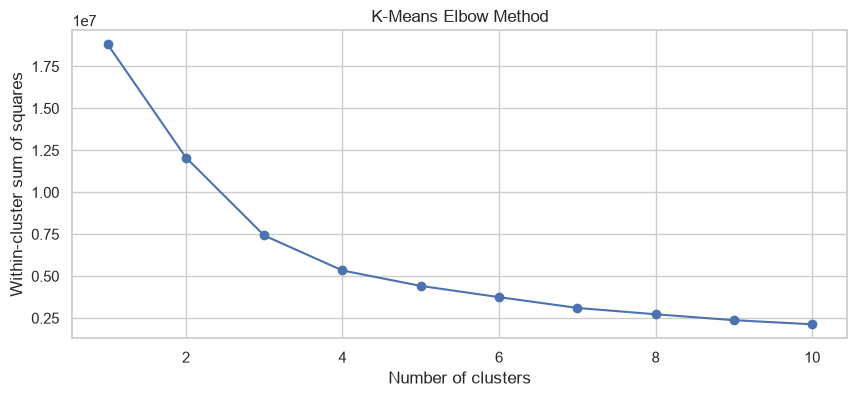

In [17]:
# The elbow curve helps select a practical number of clusters.
cluster_counts = range(1, 11)
inertia_by_cluster_count = []

for cluster_count in cluster_counts:
    trial_clusterer = KMeans(n_clusters=cluster_count, init='k-means++', max_iter=300, n_init=10, random_state=0)
    trial_clusterer.fit(condition_matrix)
    inertia_by_cluster_count.append(trial_clusterer.inertia_)

plt.figure(figsize=(10, 4))
plt.plot(cluster_counts, inertia_by_cluster_count, marker='o')
plt.title('K-Means Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Within-cluster sum of squares')
plt.show()

In [18]:
# Fit the selected four-cluster model and attach cluster assignments to crop labels.
crop_clusterer = KMeans(n_clusters=4, init='k-means++', max_iter=300, n_init=10, random_state=0)
crop_cluster_ids = crop_clusterer.fit_predict(condition_matrix)

cluster_membership = pd.concat(
    [pd.Series(crop_cluster_ids, name='cluster'), crop_recommendation_df['label']],
    axis=1
)
cluster_membership.head()

,cluster,label
0,3,rice
1,3,rice
2,3,rice
3,3,rice
4,3,rice


In [19]:
for cluster_id in sorted(cluster_membership['cluster'].unique()):
    crops_in_cluster = sorted(cluster_membership.loc[cluster_membership['cluster'] == cluster_id, 'label'].unique())
    print(f"Cluster {cluster_id}: {crops_in_cluster}")

Cluster 0: ['apple', 'grapes']
Cluster 1: ['blackgram', 'chickpea', 'coconut', 'kidneybeans', 'lentil', 'maize', 'mango', 'mothbeans', 'mungbean', 'orange', 'papaya', 'pigeonpeas', 'pomegranate']
Cluster 2: ['banana', 'coffee', 'cotton', 'maize', 'muskmelon', 'papaya', 'watermelon']
Cluster 3: ['coconut', 'coffee', 'jute', 'papaya', 'pigeonpeas', 'rice']


## 9. Supervised Crop Recommendation Models

Train and compare Logistic Regression, CatBoost, and LightGBM classifiers using the same features and train/test split.

In [20]:
model_features = crop_recommendation_df.drop(columns=['label'])
crop_labels = crop_recommendation_df['label']

print(f"Feature matrix shape: {model_features.shape}")
print(f"Target vector shape: {crop_labels.shape}")

Feature matrix shape: (2200, 7)
Target vector shape: (2200,)


In [21]:
training_features, test_features, training_labels, test_labels = train_test_split(
    model_features,
    crop_labels,
    test_size=0.2,
    random_state=0
)

print(f"training_features shape: {training_features.shape}")
print(f"test_features shape: {test_features.shape}")
print(f"training_labels shape: {training_labels.shape}")
print(f"test_labels shape: {test_labels.shape}")

training_features shape: (1760, 7)
test_features shape: (440, 7)
training_labels shape: (1760,)
test_labels shape: (440,)


In [22]:
candidate_models = {
    'Logistic Regression': LogisticRegression(),
    'CatBoost': CatBoostClassifier(random_seed=0, verbose=False, allow_writing_files=False),
    'LightGBM': LGBMClassifier(random_state=0, verbosity=-1),
}

model_results = []
trained_models = {}
test_predictions = {}

for model_name, classifier in candidate_models.items():
    classifier.fit(training_features, training_labels)
    predicted_labels = np.asarray(classifier.predict(test_features)).ravel()

    trained_models[model_name] = classifier
    test_predictions[model_name] = predicted_labels
    model_results.append(
        {
            'model': model_name,
            'accuracy': accuracy_score(test_labels, predicted_labels),
            'precision_weighted': precision_score(test_labels, predicted_labels, average='weighted'),
            'recall_weighted': recall_score(test_labels, predicted_labels, average='weighted'),
            'f1_weighted': f1_score(test_labels, predicted_labels, average='weighted'),
        }
    )

model_comparison = (
    pd.DataFrame(model_results)
    .sort_values(['accuracy', 'f1_weighted'], ascending=False)
    .reset_index(drop=True)
)

best_model_name = model_comparison.loc[0, 'model']
best_crop_recommender = trained_models[best_model_name]
best_model_predictions = test_predictions[best_model_name]

model_comparison

,model,accuracy,precision_weighted,recall_weighted,f1_weighted
0,CatBoost,0.997727,0.997831,0.997727,0.997731
1,LightGBM,0.993182,0.993379,0.993182,0.993169
2,Logistic Regression,0.968182,0.969945,0.968182,0.968117


## 10. Feature Importance

Rank the input variables by their contribution to the best-performing model.

In [23]:
if hasattr(best_crop_recommender, 'feature_importances_'):
    importance_values = best_crop_recommender.feature_importances_
elif hasattr(best_crop_recommender, 'coef_'):
    importance_values = np.abs(best_crop_recommender.coef_).mean(axis=0)
else:
    raise AttributeError(f'{best_model_name} does not expose native feature importances.')

feature_importance = (
    pd.DataFrame({
        'feature': condition_features,
        'importance': importance_values,
    })
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

feature_importance

,feature,importance
0,humidity,22.909663
1,K,18.852517
2,rainfall,18.530471
3,N,16.623266
4,P,14.739498
5,temperature,6.289375
6,ph,2.055210


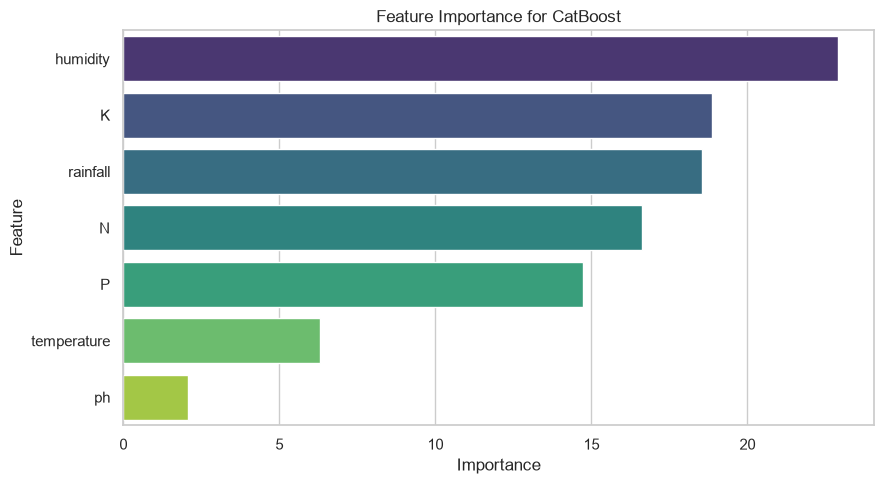

In [24]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=feature_importance,
    x='importance',
    y='feature',
    palette='viridis'
)
plt.title(f'Feature Importance for {best_model_name}')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 11. Model Evaluation

Compare the candidate classifiers and inspect the confusion matrix for the best-performing model.

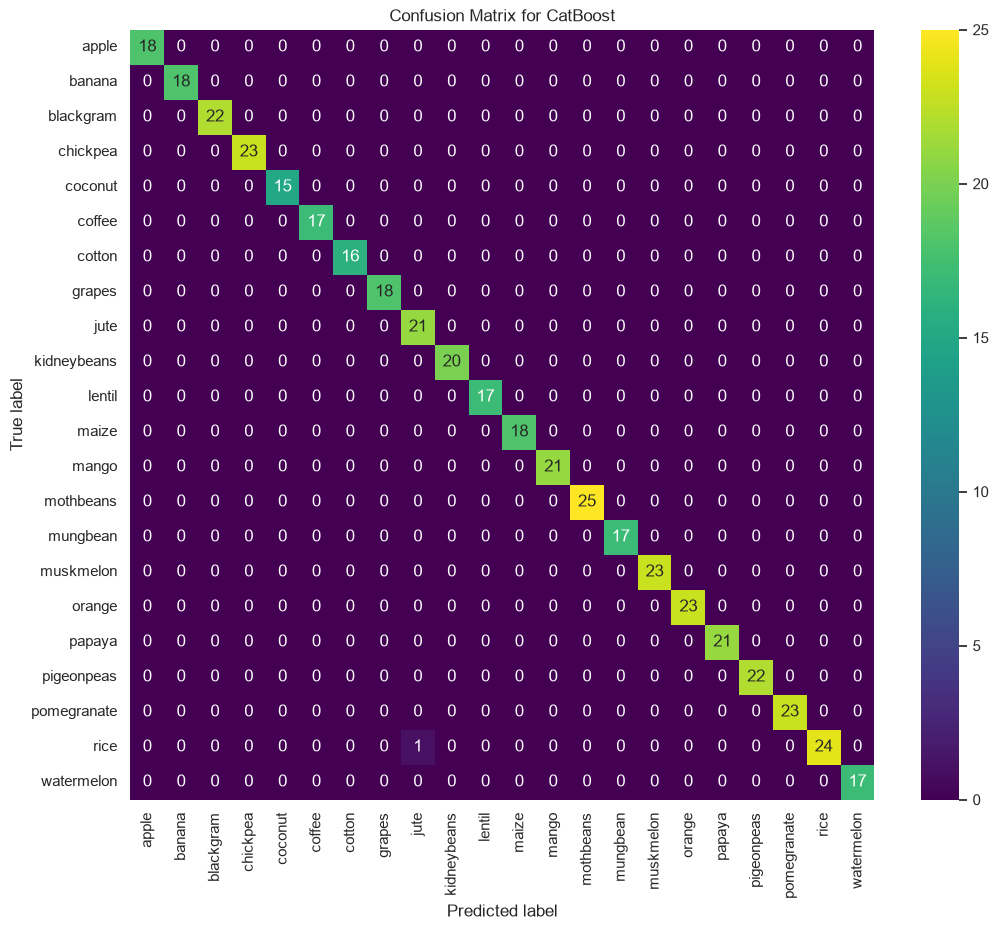

In [25]:
best_model_classes = best_crop_recommender.classes_
confusion_counts = confusion_matrix(test_labels, best_model_predictions, labels=best_model_classes)

plt.figure(figsize=(12, 10))
sns.heatmap(
    confusion_counts,
    annot=True,
    fmt='d',
    cmap='viridis',
    xticklabels=best_model_classes,
    yticklabels=best_model_classes,
)
plt.title(f'Confusion Matrix for {best_model_name}')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

In [26]:
print(f'Best model: {best_model_name}')
model_comparison.round(4)

Best model: CatBoost


,model,accuracy,precision_weighted,recall_weighted,f1_weighted
0,CatBoost,0.9977,0.9978,0.9977,0.9977
1,LightGBM,0.9932,0.9934,0.9932,0.9932
2,Logistic Regression,0.9682,0.9699,0.9682,0.9681


## 12. Example Prediction

Use the best-performing classifier to recommend a crop for a single set of soil and climate inputs.

In [27]:
example_field_conditions = pd.DataFrame(
    [[90, 40, 40, 20, 20, 7, 200]],
    columns=condition_features
)

recommended_crop = np.asarray(best_crop_recommender.predict(example_field_conditions)).ravel()
print(f"Best model: {best_model_name}")
print(f"Suggested crop: {recommended_crop[0]}")

Best model: CatBoost
Suggested crop: coffee
